In [1]:
import mujoco, mujoco.viewer
import mediapy as media
import time
import numpy as np

In [ ]:
np.array([1, 2, 3]) * 3

In [3]:
model = mujoco.MjModel.from_xml_path(r"..\external\mujoco_menagerie\unitree_a1\scene.xml")
data = mujoco.MjData(model)

dt = float(model.opt.timestep)

In [ ]:
foot_geom_names = ["FR_foot", "FL_foot", "RR_foot", "RL_foot"]
_foot_geom_ids = set(
	mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_GEOM, name)
	for name in foot_geom_names
)
_robot_geom_ids = set(
	i for i in range(model.ngeom)
	if model.geom_bodyid[i] > 0
)

In [ ]:
_foot_geom_ids, _robot_geom_ids

In [ ]:
[model.body(i).name for i in range(model.nbody)]

In [ ]:
model.geom(16)

In [ ]:
[(i, model.geom(i).name) for i in range(model.ngeom)]

Image

In [ ]:
mujoco.mj_resetDataKeyframe(model, data, 0)
mujoco.mj_forward(model, data)
data.qpos[:] += np.random.uniform(-0.05, 0.05, model.nq)
data.qvel[:] += np.random.uniform(-0.01, 0.01, model.nv)

In [11]:
def _get_euler():
	"""Extract yaw and pitch from base quaternion."""
	qw, qx, qy, qz = data.qpos[3:7]
	yaw   = np.arctan2(2*(qw*qz + qx*qy),
					1 - 2*(qy**2 + qz**2))
	pitch = np.arcsin(np.clip(2*(qw*qy - qz*qx), -1.0, 1.0))
	roll  = np.arctan2(2*(qw*qx + qy*qz),
					1 - 2*(qx**2 + qy**2))
	return float(yaw), float(pitch), float(roll)

""

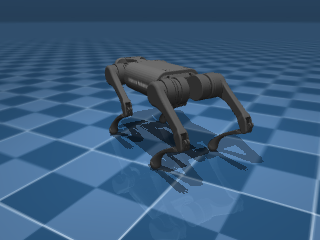

Yaw: 2.65 rad, Pitch: 0.00 rad, Roll: 0.00 rad
Relative vector: [-0.88, -0.47]


In [ ]:
mujoco.mj_resetDataKeyframe(model, data, 0)
mujoco.mj_forward(model, data)
data.qpos[6] += 4
# data.qpos[1] += 0.5
# data.qpos[:] += np.random.uniform(-0.05, 0.05, model.nq)
# data.qvel[:] += np.random.uniform(-0.1, 0.1, model.nv)
with mujoco.Renderer(model) as renderer:
	mujoco.mj_step(model, data)
	renderer.update_scene(data)
	
	media.show_image(renderer.render())

yaw, pitch, roll = _get_euler()
print(f"Yaw: {yaw:.2f} rad, Pitch: {pitch:.2f} rad, Roll: {roll:.2f} rad")

world_vector = np.array([1, 0])
cos_yaw = np.cos(-yaw)
sin_yaw = np.sin(-yaw)
relative_vector = np.array([
	cos_yaw * world_vector[0] - sin_yaw * world_vector[1],
	sin_yaw * world_vector[0] + cos_yaw * world_vector[1]
])
print(f"Relative vector: [{relative_vector[0]:.2f}, {relative_vector[1]:.2f}]")

In [6]:
data.xpos[2]

array([ 0.183, -0.047,  0.27 ])

In [37]:
duration = 1  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetDataKeyframe(model, data, 0)  # Reset state and time.
mujoco.mj_forward(model, data)
# data.qpos[:] += np.random.uniform(-0.05, 0.05, model.nq)
# data.qvel[:] += np.random.uniform(-1, 1, model.nv)
# data.qpos[2] += 0.1
data.qvel[0] = 2
with mujoco.Renderer(model) as renderer:
	while data.time < duration:
		mujoco.mj_step(model, data)
		data.qpos[5] = 0
		if len(frames) < data.time * framerate:
			#   print(data.time)
			# print(data.qpos[0:3])
			renderer.update_scene(data)
			pixels = renderer.render()
			frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


In [ ]:
data.qvel

In [ ]:
data.qpos

In [ ]:
data.qpos[4] = 1

In [ ]:
data.qpos[2] = 0.15

In [ ]:
mujoco.mj_resetData(model, data)

Video

In [7]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetDataKeyframe(model, data, 0)  # Reset state and time.
data.ctrl[:] = np.array([
    -0.1, 0.8, -1.5,   # Front Right
     0.1, 0.8, -1.5,   # Front Left
    -0.1, 1.0, -1.5,   # Rear Right
     0.1, 1.0, -1.5    # Rear Left
], dtype=np.float32)
with mujoco.Renderer(model) as renderer:
	while data.time < duration:
		mujoco.mj_step(model, data)
		if len(frames) < data.time * framerate:
			#   print(data.time)
			# print(data.qpos[0:3])
			renderer.update_scene(data)
			pixels = renderer.render()
			frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


In [10]:
data.xpos[2]

array([ 0.21665167, -0.04765689,  0.28723949])

In [ ]:
data.ctrl[:]

Live Render

In [ ]:
SPEED_MULTIPLIER = 1

with mujoco.viewer.launch_passive(model, data) as viewer:
	while viewer.is_running():
		t0 = time.perf_counter()
		mujoco.mj_step(model, data)
		viewer.sync()
		action = data.ctrl[:]
		q = data.qpos[7:19].copy()
		q_FR, q_FL, q_RR, q_RL = q[0:3], q[3:6], q[6:9], q[9:12]

		# Invert right hips for mirroring
		q_FR[0] *= -1
		q_RR[0] *= -1

		# Calculate physical lateral symmetry
		symmetry_penalty = (np.sum(np.square(q_FR - q_FL)) + np.sum(np.square(q_RR - q_RL)))
		print(f"Symmetry penalty: {symmetry_penalty:.4f}")
		while time.perf_counter() - t0 < dt * SPEED_MULTIPLIER:
			time.sleep(0)

Control Test

In [ ]:
model.actuator_ctrlrange

In [ ]:
data.ctrl

In [ ]:
data.time

In [ ]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    for i in range(len(data.ctrl)):
        magnitude = model.actuator_ctrlrange[i, 1] - model.actuator_ctrlrange[i, 0]
        median = 0.5 * (model.actuator_ctrlrange[i, 0] + model.actuator_ctrlrange[i, 1])
        data.ctrl[i] = median + 0.5 * magnitude * np.sin(2 * np.pi * data.time + i*np.pi/4)
        
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

PPO Training

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from env import UnitreeA1Env

xmlPath = r"..\external\mujoco_menagerie\unitree_a1\scene.xml"

In [ ]:
# Train live view

env = UnitreeA1Env(xmlPath, render_mode="human")
model = PPO("MlpPolicy", env, verbose=1)

obs, _ = env.reset()
episode_reward = 0
episode_rewards = []

for step in range(50_000):
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, _ = env.step(action)
    env.render()
    episode_reward += reward

    if terminated or truncated:
        episode_rewards.append(episode_reward)
        episode_reward = 0
        obs, _ = env.reset()

        # Print every 10 episodes
        if len(episode_rewards) % 10 == 0:
            mean = sum(episode_rewards[-10:]) / 10
            print(f"Episode {len(episode_rewards)} | Mean reward (last 10): {mean:.2f}")

In [ ]:
# Headless training

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback

xml = r"..\external\mujoco_menagerie\unitree_a1\scene.xml"

class LogCallback(BaseCallback):
    def _on_step(self):
        if len(self.model.ep_info_buffer) > 0 and self.n_calls % 10_000 == 0:
            mean_reward = np.mean([e["r"] for e in self.model.ep_info_buffer])
            mean_len    = np.mean([e["l"] for e in self.model.ep_info_buffer])
            print(f"steps={self.num_timesteps:>8} | mean_ep_reward={mean_reward:>8.2f} | mean_ep_len={mean_len:>6.0f}")
        return True

env = make_vec_env(lambda: UnitreeA1Env(xml), n_envs=4)

model = PPO(
    "MlpPolicy",
    env,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,       # small entropy bonus helps exploration
    learning_rate=3e-4,
    verbose=0,           # silence SB3's own output, use our callback instead
    tensorboard_log="./tb_logs/",
)

model.learn(total_timesteps=5_000_000, callback=LogCallback())
model.save("a1_walk_v1")

Load a model

In [ ]:
from stable_baselines3 import PPO
import numpy as np

# Load the trained model
model = PPO.load(r"..\Models\a1_walk_v1")

# Create a render env
env = UnitreeA1Env(xml, render_mode="human")
obs, _ = env.reset()

while True:
    action, _ = model.predict(obs, deterministic=True)  # deterministic=True = no random sampling
    obs, reward, terminated, truncated, _ = env.step(action)
    env.render()
    if terminated or truncated:
        obs, _ = env.reset()

export a 10 second video at 60 FPS of the model

In [ ]:
from record_video import record_video
record_video(
    model_path="a1_walk_v1",
	env=UnitreeA1Env,
    xml_path=r".\external\mujoco_menagerie\unitree_a1\scene.xml",
    output_path="a1_progress_5m_steps.mp4",
    duration_seconds=10,
    fps=60
)